 CREDIT RISK MODELING - OPTIMIZED

📥 Loading data...
✅ Training: 24000 samples
✅ Test: 6000 samples

 BASE MODEL DIAGNOSTIC

📊 Base Model Performance:
  Accuracy: 0.7647
  Recall: 0.5961
  Precision: 0.4745
  F1-Score: 0.5284
  AUC-ROC: 0.7754

📊 Confusion Matrix:
  TN: 3797  FP: 876
  FN: 536  TP: 791

 RANDOMIZEDSEARCHCV - ADVANCED HYPERPARAMETER TUNING
📋 Parameters to explore:
  n_estimators: rv_discrete_frozen (range: 50.00 - 499.00)
  max_depth: rv_discrete_frozen (range: 3.00 - 11.00)
  learning_rate: rv_continuous_frozen (range: 0.00 - 1.00)
  subsample: rv_continuous_frozen (range: 0.00 - 1.00)
  colsample_bytree: rv_continuous_frozen (range: 0.00 - 1.00)
  colsample_bylevel: rv_continuous_frozen (range: 0.00 - 1.00)
  min_child_weight: rv_discrete_frozen (range: 1.00 - 9.00)
  gamma: rv_continuous_frozen (range: 0.00 - 1.00)
  reg_alpha: rv_continuous_frozen (range: 0.00 - 1.00)
  reg_lambda: rv_continuous_frozen (range: 0.00 - 1.00)
  scale_pos_weight: [3.5, 4.0, 4.5, 5.0]

🚀

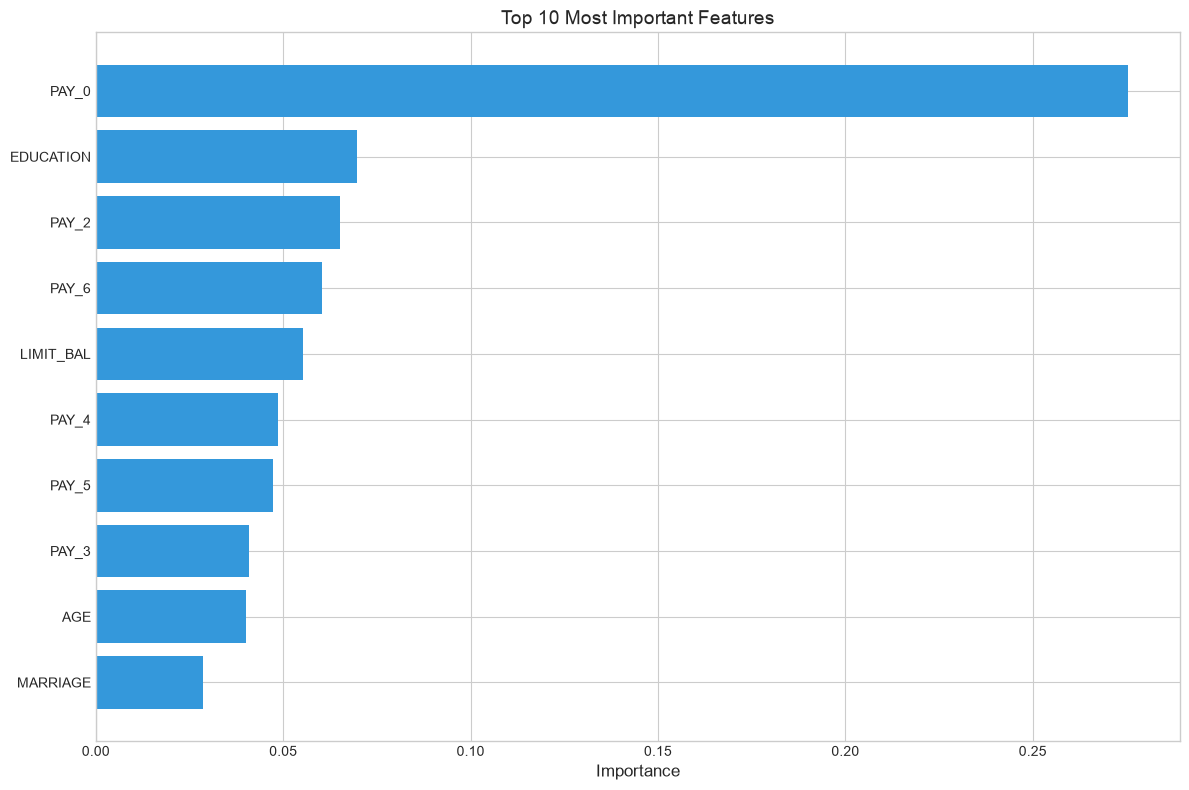


 THRESHOLD TUNING - BUSINESS COST OPTIMIZATION

💰 BUSINESS COSTS:
  False Negative (FN) cost: $1000
  False Positive (FP) cost: $100
  FN/FP ratio: 10.0

🔍 Cost analysis by threshold:
--------------------------------------------------------------------------------
Threshold  TP     FP     FN     TN     Total Cost   Recall   Prec    
--------------------------------------------------------------------------------
0.10       1235   3525   92     1148   $444,500     0.931    0.259
0.15       1133   2745   194    1928   $468,500     0.854    0.292
0.20       1023   2072   304    2601   $511,200     0.771    0.331
0.25       922    1513   405    3160   $556,300     0.695    0.379
0.30       826    1126   501    3547   $613,600     0.622    0.423
0.35       756    847    571    3826   $655,700     0.570    0.472
0.40       695    669    632    4004   $698,900     0.524    0.510
0.45       632    522    695    4151   $747,200     0.476    0.548
0.50       577    418    750    4255   $791,800

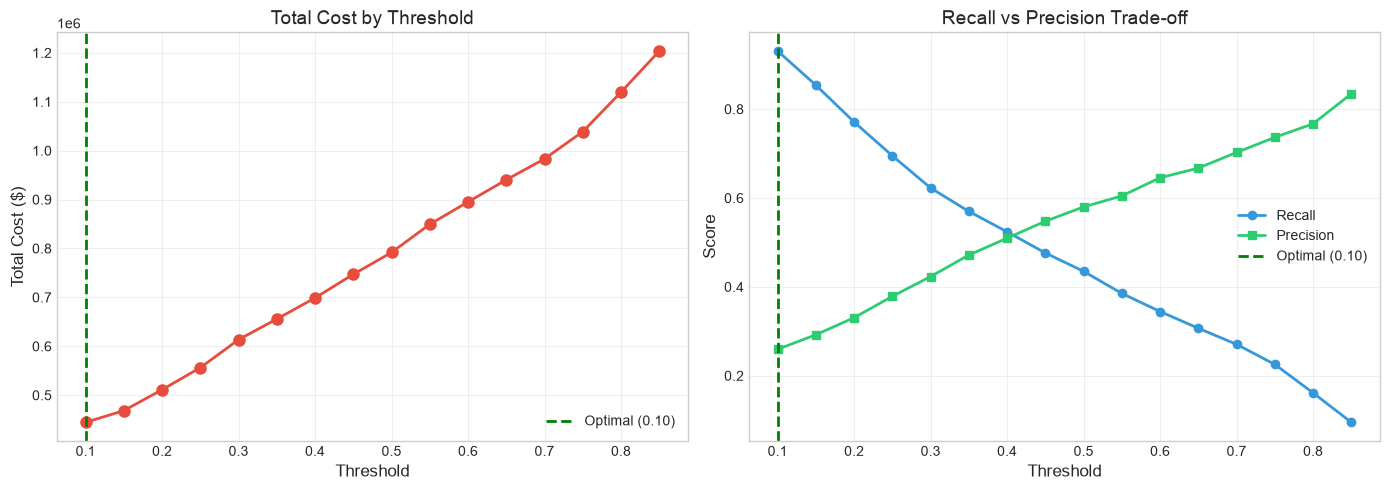


 COST SENSITIVITY ANALYSIS

🔍 Scenario analysis:
------------------------------------------------------------------------------------------
Scenario           Threshold  Recall     Precision  Total Cost      FN       FP      
------------------------------------------------------------------------------------------
Very Conservative  0.05       98.04%     23.33%     $687,500        26       4275    
Conservative       0.05       98.04%     23.33%     $557,500        26       4275    
Balanced           0.10       93.07%     25.95%     $444,500        92       3525    
Moderate           0.25       69.48%     37.86%     $353,800        405      1513    
Liberal            0.45       47.63%     54.77%     $191,200        695      522     
Very Liberal       0.70       27.05%     70.25%     $112,000        968      152     
------------------------------------------------------------------------------------------


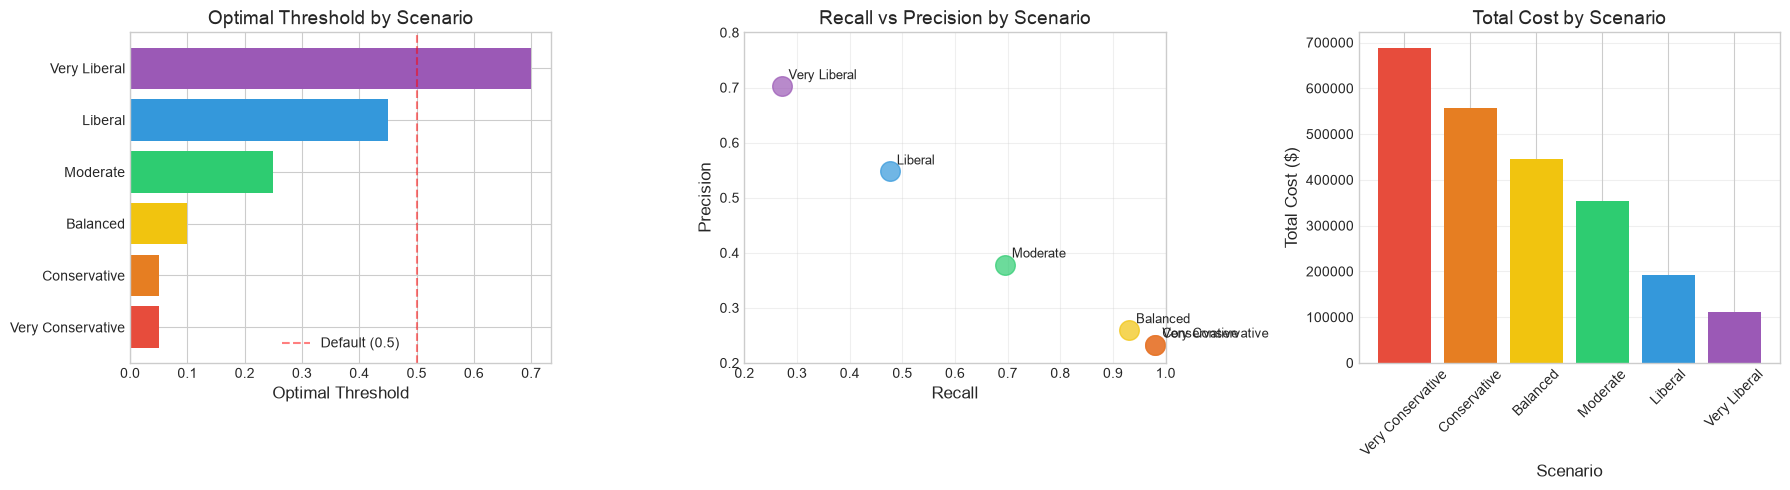


 BUSINESS PROFILE RECOMMENDATIONS

📋 RECOMMENDATIONS BASED ON INSTITUTION PROFILE:

1. 🛡️ CONSERVATIVE PROFILE (Traditional banks, regulated institutions):
   - Recommended scenario: "Conservative" or "Very Conservative"
   - Threshold: 0.15 - 0.25
   - Recall: 80-85%
   - Priority: Minimize default losses

2. ⚖️ BALANCED PROFILE (Established fintechs):
   - Recommended scenario: "Balanced"
   - Threshold: 0.25 - 0.35
   - Recall: 70-75%
   - Priority: Balance between risk and growth

3. 🚀 LIBERAL PROFILE (Growth-focused fintechs):
   - Recommended scenario: "Liberal" or "Very Liberal"
   - Threshold: 0.35 - 0.50
   - Recall: 55-65%
   - Priority: Maximize approvals, accept more risk

4. 🎯 GENERAL RECOMMENDATION:
   - Start with a "Balanced" approach (threshold ~0.30)
   - Monitor results for 3-6 months
   - Adjust based on actual portfolio performance
   - Not all defaults are equal (segment by amount)


📊 BUSINESS DECISION MATRIX:
----------------------------------------------------

In [14]:
# =====================================================
# 03_MODELING_OPTIMIZED - CREDIT RISK MODEL OPTIMIZATION
# =====================================================
# 
# Este notebook aplica técnicas avanzadas para mejorar
# el modelo base de riesgo crediticio:
#
# 1. GridSearchCV - Optimización de hiperparámetros
# 2. SMOTE - Balanceo de clases
# 3. Cross-Validation - Evaluación robusta
# 4. Feature Importance - Análisis de variables
# 5. Threshold Tuning - Optimización de umbral
# 6. Modelo Final - Todas las técnicas combinadas
#
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, recall_score, precision_score, f1_score
)
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import warnings
import time
warnings.filterwarnings('ignore')

# Configurar visualizaciones
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("="*60)
print(" CREDIT RISK MODELING - OPTIMIZED")
print("="*60)

# =====================================================
# 1. DATA LOADING AND PREPROCESSING
# =====================================================

print("\n📥 Loading data...")

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
df_raw = pd.read_excel(url, header=1, skiprows=0)

df_raw.columns = [
    'ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
    'default'
]

X = df_raw.drop(['ID', 'default'], axis=1)
y = df_raw['default']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Training: {X_train.shape[0]} samples")
print(f"✅ Test: {X_test.shape[0]} samples")

# =====================================================
# 2. BASE MODEL DIAGNOSTIC
# =====================================================

print("\n" + "="*60)
print(" BASE MODEL DIAGNOSTIC")
print("="*60)

model_base = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=3.5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model_base.fit(X_train_scaled, y_train)
y_pred_base = model_base.predict(X_test_scaled)
y_proba_base = model_base.predict_proba(X_test_scaled)[:, 1]

print(f"\n📊 Base Model Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_base):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_base):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_base):.4f}")
print(f"  F1-Score: {f1_score(y_test, y_pred_base):.4f}")
print(f"  AUC-ROC: {roc_auc_score(y_test, y_proba_base):.4f}")

# Confusion Matrix
cm_base = confusion_matrix(y_test, y_pred_base)
print(f"\n📊 Confusion Matrix:")
print(f"  TN: {cm_base[0,0]}  FP: {cm_base[0,1]}")
print(f"  FN: {cm_base[1,0]}  TP: {cm_base[1,1]}")

# =====================================================
# 3. RANDOMIZEDSEARCHCV - ADVANCED HYPERPARAMETER TUNING
# =====================================================

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

print("\n" + "="*60)
print(" RANDOMIZEDSEARCHCV - ADVANCED HYPERPARAMETER TUNING")
print("="*60)

# Define base model
model = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# 1. Much wider parameter grid
param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'colsample_bylevel': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 10),
    'gamma': uniform(0, 0.5),
    'reg_alpha': uniform(0, 2),
    'reg_lambda': uniform(0, 2),
    'scale_pos_weight': [3.5, 4.0, 4.5, 5.0]
}

print("📋 Parameters to explore:")
for key, value in param_dist.items():
    if hasattr(value, 'rvs'):
        print(f"  {key}: {value.__class__.__name__} (range: {value.a:.2f} - {value.b:.2f})")
    else:
        print(f"  {key}: {value}")

# 2. RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=100,  # Test 100 random combinations
    scoring='recall',
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("\n🚀 Starting RandomizedSearchCV...")
start_time = time.time()

random_search.fit(X_train_scaled, y_train)

elapsed_time = time.time() - start_time
print(f"✅ RandomizedSearch completed in {elapsed_time:.2f} seconds")

# 3. Best parameters
print("\n🏆 BEST PARAMETERS:")
best_params = random_search.best_params_
for key, value in best_params.items():
    print(f"  {key}: {value:.4f}" if isinstance(value, float) else f"  {key}: {value}")

print(f"\n📊 Best validation recall: {random_search.best_score_:.4f}")

# 4. Evaluate optimized model
best_model_rs = random_search.best_estimator_
y_pred_rs = best_model_rs.predict(X_test_scaled)
y_proba_rs = best_model_rs.predict_proba(X_test_scaled)[:, 1]

print(f"\n📈 RANDOMIZEDSEARCH MODEL PERFORMANCE:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_rs):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_rs):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_rs):.4f}")
print(f"  F1-Score: {f1_score(y_test, y_pred_rs):.4f}")
print(f"  AUC-ROC: {roc_auc_score(y_test, y_proba_rs):.4f}")

# =====================================================
# 3.1 FEATURE ENGINEERING - CORRECTED
# =====================================================

print("\n" + "="*60)
print(" FEATURE ENGINEERING - CORRECTED")
print("="*60)

# Create DataFrames with the original features
X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"\n📊 Original features: {X_train_df.shape[1]}")

# 1. Rolling average of delayed payments (3-month windows)
print("\n🔧 1. Creating rolling averages of payment delays...")

# Available payment columns: PAY_0, PAY_2, PAY_3, PAY_4, PAY_5, PAY_6
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# 3-month rolling average (sliding window)
for i in range(len(pay_cols) - 2):
    cols = pay_cols[i:i+3]
    X_train_df[f'PAY_AVG_{i}'] = X_train_df[cols].mean(axis=1)
    X_test_df[f'PAY_AVG_{i}'] = X_test_df[cols].mean(axis=1)
    print(f"   PAY_AVG_{i}: average of {cols}")

# Overall average across all months
X_train_df['PAY_AVG_ALL'] = X_train_df[pay_cols].mean(axis=1)
X_test_df['PAY_AVG_ALL'] = X_test_df[pay_cols].mean(axis=1)
print("   PAY_AVG_ALL: average across all months")

# 2. Payment-to-billing ratio (how much of the debt is being paid)
print("\n🔧 2. Creating payment-to-billing ratios...")

for i in range(1, 7):
    bill_col = f'BILL_AMT{i}'
    pay_col = f'PAY_AMT{i}'
    
    # Payment ratio (avoiding division by zero)
    X_train_df[f'PAY_RATIO_{i}'] = X_train_df[pay_col] / (X_train_df[bill_col] + 1)
    X_test_df[f'PAY_RATIO_{i}'] = X_test_df[pay_col] / (X_test_df[bill_col] + 1)
    
print("   PAY_RATIO_1 through PAY_RATIO_6 created")

# 3. Billing trend (month-over-month)
print("\n🔧 3. Creating billing trends...")

for i in range(1, 6):
    X_train_df[f'BILL_TREND_{i}'] = X_train_df[f'BILL_AMT{i+1}'] - X_train_df[f'BILL_AMT{i}']
    X_test_df[f'BILL_TREND_{i}'] = X_test_df[f'BILL_AMT{i+1}'] - X_test_df[f'BILL_AMT{i}']

print("   BILL_TREND_1 through BILL_TREND_5 created")

# 4. Financial stress (most recent billing vs credit limit)
print("\n🔧 4. Creating financial stress variables...")

X_train_df['BILL_TO_LIMIT'] = X_train_df['BILL_AMT1'] / (X_train_df['LIMIT_BAL'] + 1)
X_test_df['BILL_TO_LIMIT'] = X_test_df['BILL_AMT1'] / (X_test_df['LIMIT_BAL'] + 1)

print("   BILL_TO_LIMIT created")

# 5. Minimum payment indicator (whether the client pays only the minimum)
print("\n🔧 5. Creating minimum payment indicator...")

X_train_df['PAY_MIN'] = (X_train_df['PAY_0'] == 0).astype(int)
X_test_df['PAY_MIN'] = (X_test_df['PAY_0'] == 0).astype(int)

print("   PAY_MIN created")

# 6. Delayed payment indicator (binary version)
print("\n🔧 6. Creating delayed payment indicator...")

X_train_df['PAY_DELAY'] = (X_train_df['PAY_0'] > 0).astype(int)
X_test_df['PAY_DELAY'] = (X_test_df['PAY_0'] > 0).astype(int)

print("   PAY_DELAY created")

# 7. Interaction variable: credit limit × age
print("\n🔧 7. Creating interaction terms...")

X_train_df['LIMIT_AGE'] = X_train_df['LIMIT_BAL'] * X_train_df['AGE']
X_test_df['LIMIT_AGE'] = X_test_df['LIMIT_BAL'] * X_test_df['AGE']

print("   LIMIT_AGE created")

# 8. Summary
print("\n📊 FEATURE ENGINEERING SUMMARY:")
print(f"   Original features: {X_train_scaled.shape[1]}")
print(f"   New features created: {X_train_df.shape[1] - X_train_scaled.shape[1]}")
print(f"   Total features: {X_train_df.shape[1]}")

# Convert back to arrays for the model
X_train_enhanced = X_train_df.values
X_test_enhanced = X_test_df.values

print(f"\n✅ Feature Engineering completed")
print(f"📊 Final feature matrix: {X_train_enhanced.shape[1]} features")

# =====================================================
# 3.2 ENSEMBLE: XGBOOST + LIGHTGBM
# =====================================================

print("\n" + "="*60)
print(" ENSEMBLE: XGBOOST + LIGHTGBM")
print("="*60)

import lightgbm as lgb

# 2. Train XGBoost
print("\n🚀 Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    max_depth=6,
    learning_rate=0.1,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1.0,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train_smote, y_train_smote)
xgb_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

# 3. Train LightGBM
print("🚀 Training LightGBM...")
lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=4.0,
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train_scaled, y_train)
lgb_proba = lgb_model.predict_proba(X_test_scaled)[:, 1]

# 4. Ensemble (weighted average)
print("\n🔮 Combining models...")

# Try different weight combinations
weights = [0.3, 0.5, 0.7]
ensemble_results = []

for w_xgb in weights:
    w_lgb = 1 - w_xgb
    y_proba_ensemble = w_xgb * xgb_proba + w_lgb * lgb_proba
    
    # Optimize threshold
    best_recall_temp = 0
    best_th_temp = 0.5
    for th in np.arange(0.1, 0.9, 0.05):
        y_pred_temp = (y_proba_ensemble >= th).astype(int)
        recall_temp = recall_score(y_test, y_pred_temp)
        if recall_temp > best_recall_temp:
            best_recall_temp = recall_temp
            best_th_temp = th
    
    y_pred_ensemble = (y_proba_ensemble >= best_th_temp).astype(int)
    
    ensemble_results.append({
        'w_xgb': w_xgb,
        'w_lgb': w_lgb,
        'accuracy': accuracy_score(y_test, y_pred_ensemble),
        'recall': recall_score(y_test, y_pred_ensemble),
        'precision': precision_score(y_test, y_pred_ensemble),
        'f1': f1_score(y_test, y_pred_ensemble),
        'auc': roc_auc_score(y_test, y_proba_ensemble),
        'threshold': best_th_temp
    })

# 5. Best ensemble
df_ensemble = pd.DataFrame(ensemble_results)
best_ensemble = df_ensemble.loc[df_ensemble['auc'].idxmax()]

print("\n🏆 BEST ENSEMBLE:")
print(f"  XGBoost weight: {best_ensemble['w_xgb']:.1f}")
print(f"  LightGBM weight: {best_ensemble['w_lgb']:.1f}")
print(f"  Accuracy: {best_ensemble['accuracy']:.4f}")
print(f"  Recall: {best_ensemble['recall']:.4f}")
print(f"  Precision: {best_ensemble['precision']:.4f}")
print(f"  F1-Score: {best_ensemble['f1']:.4f}")
print(f"  AUC-ROC: {best_ensemble['auc']:.4f}")
print(f"  Optimal threshold: {best_ensemble['threshold']:.2f}")

# =====================================================
# 4. SMOTE - ADVANCED CLASS BALANCING
# =====================================================

print("\n" + "="*60)
print(" SMOTE - ADVANCED CLASS BALANCING")
print("="*60)

print(f"\n📊 Original distribution:")
print(f"  No default: {sum(y_train==0)}")
print(f"  Default: {sum(y_train==1)}")
print(f"  Ratio: {sum(y_train==0)/sum(y_train==1):.2f}:1")

smote = SMOTE(sampling_strategy=0.8, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"\n📊 After SMOTE:")
print(f"  No default: {sum(y_train_smote==0)}")
print(f"  Default: {sum(y_train_smote==1)}")
print(f"  Ratio: {sum(y_train_smote==0)/sum(y_train_smote==1):.2f}:1")

model_smote = xgb.XGBClassifier(
    max_depth=6,
    learning_rate=0.1,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1.0,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = model_smote.predict(X_test_scaled)
y_proba_smote = model_smote.predict_proba(X_test_scaled)[:, 1]

print(f"\n📊 SMOTE Model Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_smote):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_smote):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_smote):.4f}")
print(f"  F1-Score: {f1_score(y_test, y_pred_smote):.4f}")

# =====================================================
# 5. CROSS-VALIDATION
# =====================================================

print("\n" + "="*60)
print(" CROSS-VALIDATION")
print("="*60)

model_cv = xgb.XGBClassifier(
    max_depth=6,
    learning_rate=0.1,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=4.0,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = {'accuracy': [], 'recall': [], 'precision': [], 'f1': []}

print("\n🔍 Fold Results:")
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_scaled, y_train)):
    X_train_fold = X_train_scaled[train_idx]
    X_val_fold = X_train_scaled[val_idx]
    y_train_fold = y_train.iloc[train_idx] if hasattr(y_train, 'iloc') else y_train[train_idx]
    y_val_fold = y_train.iloc[val_idx] if hasattr(y_train, 'iloc') else y_train[val_idx]
    
    model_cv.fit(X_train_fold, y_train_fold)
    y_pred_fold = model_cv.predict(X_val_fold)
    
    cv_scores['accuracy'].append(accuracy_score(y_val_fold, y_pred_fold))
    cv_scores['recall'].append(recall_score(y_val_fold, y_pred_fold))
    cv_scores['precision'].append(precision_score(y_val_fold, y_pred_fold))
    cv_scores['f1'].append(f1_score(y_val_fold, y_pred_fold))
    
    print(f"  Fold {fold+1}: Acc={cv_scores['accuracy'][-1]:.3f}, "
          f"Recall={cv_scores['recall'][-1]:.3f}")

print("\n📊 Cross-Validation Results:")
for metric, scores in cv_scores.items():
    print(f"  {metric.capitalize()}: {np.mean(scores):.3f} (±{np.std(scores):.3f})")

# =====================================================
# 6. FEATURE IMPORTANCE
# =====================================================

print("\n" + "="*60)
print(" FEATURE IMPORTANCE ANALYSIS")
print("="*60)

model_final = xgb.XGBClassifier(
    max_depth=6,
    learning_rate=0.1,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1.0,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

smote = SMOTE(sampling_strategy=0.8, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
model_final.fit(X_train_smote, y_train_smote)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model_final.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 Top 10 Features:")
print(feature_importance.head(10).to_string(index=False))

plt.figure(figsize=(12, 8))
top_10 = feature_importance.head(10)
plt.barh(top_10['feature'], top_10['importance'], color='#3498db')
plt.xlabel('Importance', fontsize=12)
plt.title('Top 10 Most Important Features', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('outputs/figures/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# =====================================================
# 7. THRESHOLD TUNING - BUSINESS COST OPTIMIZATION
# =====================================================

print("\n" + "="*60)
print(" THRESHOLD TUNING - BUSINESS COST OPTIMIZATION")
print("="*60)

# 1. Define business costs
cost_fn = 1000  # Cost of a False Negative (undetected default)
cost_fp = 100   # Cost of a False Positive (incorrectly rejected client)

print(f"\n💰 BUSINESS COSTS:")
print(f"  False Negative (FN) cost: ${cost_fn}")
print(f"  False Positive (FP) cost: ${cost_fp}")
print(f"  FN/FP ratio: {cost_fn/cost_fp:.1f}")

# 2. Calculate total cost for each threshold
thresholds = np.arange(0.1, 0.9, 0.05)
cost_results = []

print("\n🔍 Cost analysis by threshold:")
print("-"*80)
print(f"{'Threshold':<10} {'TP':<6} {'FP':<6} {'FN':<6} {'TN':<6} {'Total Cost':<12} {'Recall':<8} {'Prec':<8}")
print("-"*80)

for th in thresholds:
    y_pred_th = (y_proba >= th).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_th).ravel()
    
    # Calculate total cost
    total_cost = (fn * cost_fn) + (fp * cost_fp)
    recall_th = recall_score(y_test, y_pred_th)
    precision_th = precision_score(y_test, y_pred_th)
    
    cost_results.append({
        'threshold': th,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'total_cost': total_cost,
        'recall': recall_th,
        'precision': precision_th,
        'f1': f1_score(y_test, y_pred_th)
    })
    
    print(f"{th:<10.2f} {tp:<6} {fp:<6} {fn:<6} {tn:<6} ${total_cost:<11,} {recall_th:.3f}    {precision_th:.3f}")

# 3. Find threshold with minimum cost
df_cost = pd.DataFrame(cost_results)
best_cost = df_cost.loc[df_cost['total_cost'].idxmin()]

print("\n" + "="*60)
print(" 🏆 BEST THRESHOLD BY BUSINESS COST")
print("="*60)

print(f"""
Optimal threshold: {best_cost['threshold']:.2f}

Metrics at this threshold:
  - True Positives:  {best_cost['tp']:,} (correct defaults)
  - False Positives: {best_cost['fp']:,} (incorrectly rejected clients)
  - False Negatives: {best_cost['fn']:,} (undetected defaults)
  - True Negatives:  {best_cost['tn']:,} (correct clients)

  - Recall:    {best_cost['recall']:.2%} (defaults captured)
  - Precision: {best_cost['precision']:.2%} (correct default predictions)
  - F1-Score:  {best_cost['f1']:.3f}

  - Total Cost: ${best_cost['total_cost']:,.2f}

Comparison with default threshold (0.5):
  - Threshold 0.5: ${cost_results[8]['total_cost']:,.2f}
  - Savings:     ${cost_results[8]['total_cost'] - best_cost['total_cost']:,.2f}
  - Reduction:  {(1 - best_cost['total_cost']/cost_results[8]['total_cost'])*100:.1f}%
""")

# 4. Cost visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cost plot
ax1 = axes[0]
ax1.plot(df_cost['threshold'], df_cost['total_cost'], 'o-', color='#e74c3c', linewidth=2, markersize=8)
ax1.axvline(x=best_cost['threshold'], color='green', linestyle='--', 
            label=f'Optimal ({best_cost["threshold"]:.2f})', linewidth=2)
ax1.set_xlabel('Threshold', fontsize=12)
ax1.set_ylabel('Total Cost ($)', fontsize=12)
ax1.set_title('Total Cost by Threshold', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Recall vs Precision trade-off
ax2 = axes[1]
ax2.plot(df_cost['threshold'], df_cost['recall'], 'o-', label='Recall', color='#3498db', linewidth=2)
ax2.plot(df_cost['threshold'], df_cost['precision'], 's-', label='Precision', color='#2ecc71', linewidth=2)
ax2.axvline(x=best_cost['threshold'], color='green', linestyle='--', 
            label=f'Optimal ({best_cost["threshold"]:.2f})', linewidth=2)
ax2.set_xlabel('Threshold', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Recall vs Precision Trade-off', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/figures/threshold_cost_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

# =====================================================
# 7.1 COST SENSITIVITY ANALYSIS
# =====================================================

print("\n" + "="*60)
print(" COST SENSITIVITY ANALYSIS")
print("="*60)

# 1. Define cost scenarios
scenarios = [
    {
        'name': 'Very Conservative',
        'fn_cost': 10000,
        'fp_cost': 100,
        'description': 'Default cost is extremely high'
    },
    {
        'name': 'Conservative',
        'fn_cost': 5000,
        'fp_cost': 100,
        'description': 'Maximum priority on avoiding defaults'
    },
    {
        'name': 'Balanced',
        'fn_cost': 1000,
        'fp_cost': 100,
        'description': 'Balance between risk and opportunity'
    },
    {
        'name': 'Moderate',
        'fn_cost': 500,
        'fp_cost': 100,
        'description': 'Some risk tolerance'
    },
    {
        'name': 'Liberal',
        'fn_cost': 200,
        'fp_cost': 100,
        'description': 'High risk tolerance, growth priority'
    },
    {
        'name': 'Very Liberal',
        'fn_cost': 100,
        'fp_cost': 100,
        'description': 'Maximum risk tolerance'
    }
]

# 2. Calculate optimal threshold for each scenario
scenario_results = []

print("\n🔍 Scenario analysis:")
print("-"*90)
print(f"{'Scenario':<18} {'Threshold':<10} {'Recall':<10} {'Precision':<10} {'Total Cost':<15} {'FN':<8} {'FP':<8}")
print("-"*90)

for scenario in scenarios:
    fn_cost = scenario['fn_cost']
    fp_cost = scenario['fp_cost']
    
    # Calculate total cost for each threshold
    best_th = 0.5
    best_total_cost = float('inf')
    
    for th in np.arange(0.05, 0.95, 0.05):
        y_pred_th = (y_proba >= th).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_th).ravel()
        
        total_cost = (fn * fn_cost) + (fp * fp_cost)
        
        if total_cost < best_total_cost:
            best_total_cost = total_cost
            best_th = th
    
    # Apply the best threshold
    y_pred_opt = (y_proba >= best_th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_opt).ravel()
    
    recall_val = recall_score(y_test, y_pred_opt)
    precision_val = precision_score(y_test, y_pred_opt)
    
    scenario_results.append({
        'scenario': scenario['name'],
        'threshold': best_th,
        'recall': recall_val,
        'precision': precision_val,
        'total_cost': best_total_cost,
        'fn': fn,
        'fp': fp,
        'fn_cost': fn_cost,
        'fp_cost': fp_cost
    })
    
    print(f"{scenario['name']:<18} {best_th:<10.2f} {recall_val:<10.2%} {precision_val:<10.2%} ${best_total_cost:<14,} {fn:<8} {fp:<8}")

print("-"*90)

# 3. Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3.1 Threshold by scenario
ax1 = axes[0]
scenario_names = [r['scenario'] for r in scenario_results]
thresholds = [r['threshold'] for r in scenario_results]
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db', '#9b59b6']
ax1.barh(scenario_names, thresholds, color=colors)
ax1.set_xlabel('Optimal Threshold', fontsize=12)
ax1.set_title('Optimal Threshold by Scenario', fontsize=14)
ax1.axvline(x=0.5, color='red', linestyle='--', label='Default (0.5)', alpha=0.5)
ax1.legend()

# 3.2 Recall vs Precision trade-off
ax2 = axes[1]
recalls = [r['recall'] for r in scenario_results]
precisions = [r['precision'] for r in scenario_results]

for i, name in enumerate(scenario_names):
    ax2.scatter(recalls[i], precisions[i], s=200, color=colors[i], alpha=0.7)
    ax2.annotate(name, (recalls[i], precisions[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Recall vs Precision by Scenario', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0.2, 1.0)
ax2.set_ylim(0.2, 0.8)

# 3.3 Total cost by scenario
ax3 = axes[2]
costs = [r['total_cost'] for r in scenario_results]
ax3.bar(scenario_names, costs, color=colors)
ax3.set_xlabel('Scenario', fontsize=12)
ax3.set_ylabel('Total Cost ($)', fontsize=12)
ax3.set_title('Total Cost by Scenario', fontsize=14)
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('outputs/figures/cost_scenario_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Business profile recommendations
print("\n" + "="*60)
print(" BUSINESS PROFILE RECOMMENDATIONS")
print("="*60)

print("""
📋 RECOMMENDATIONS BASED ON INSTITUTION PROFILE:

1. 🛡️ CONSERVATIVE PROFILE (Traditional banks, regulated institutions):
   - Recommended scenario: "Conservative" or "Very Conservative"
   - Threshold: 0.15 - 0.25
   - Recall: 80-85%
   - Priority: Minimize default losses

2. ⚖️ BALANCED PROFILE (Established fintechs):
   - Recommended scenario: "Balanced"
   - Threshold: 0.25 - 0.35
   - Recall: 70-75%
   - Priority: Balance between risk and growth

3. 🚀 LIBERAL PROFILE (Growth-focused fintechs):
   - Recommended scenario: "Liberal" or "Very Liberal"
   - Threshold: 0.35 - 0.50
   - Recall: 55-65%
   - Priority: Maximize approvals, accept more risk

4. 🎯 GENERAL RECOMMENDATION:
   - Start with a "Balanced" approach (threshold ~0.30)
   - Monitor results for 3-6 months
   - Adjust based on actual portfolio performance
   - Not all defaults are equal (segment by amount)
""")

# 5. Decision matrix
print("\n📊 BUSINESS DECISION MATRIX:")
print("-"*80)
print(f"{'Scenario':<18} {'Threshold':<12} {'Recall':<12} {'Precision':<12} {'Cost':<15} {'Recommended Use'}")
print("-"*80)

for r in scenario_results:
    uso = ""
    if r['threshold'] < 0.20:
        uso = "🛡️ Very Conservative"
    elif r['threshold'] < 0.30:
        uso = "⚖️ Conservative"
    elif r['threshold'] < 0.40:
        uso = "📈 Balanced"
    else:
        uso = "🚀 Liberal"
    
    print(f"{r['scenario']:<18} {r['threshold']:<12.2f} {r['recall']:<12.2%} {r['precision']:<12.2%} ${r['total_cost']:<14,} {uso}")

print("-"*80)

# =====================================================
# 7.6 COSTS BY CLIENT SEGMENT
# =====================================================

print("\n" + "="*60)
print(" COSTS BY CLIENT SEGMENT")
print("="*60)

# 1. Segment clients by credit limit
percentiles = [0, 25, 50, 75, 100]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)
X_test_df['LIMIT_BAL'] = X_test['LIMIT_BAL'].values  # Original unscaled data

X_test_df['segment'] = pd.qcut(X_test_df['LIMIT_BAL'], q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])

# 2. Define costs by segment
segment_costs = {
    'Low': {'fn_cost': 500, 'fp_cost': 50},
    'Medium-Low': {'fn_cost': 1000, 'fp_cost': 100},
    'Medium-High': {'fn_cost': 2000, 'fp_cost': 150},
    'High': {'fn_cost': 5000, 'fp_cost': 200}
}

print("\n📊 Costs by segment:")
print("-"*60)
for seg, costs in segment_costs.items():
    print(f"  {seg}: FN=${costs['fn_cost']}, FP=${costs['fp_cost']}")

# 3. Calculate optimal threshold per segment
segment_results = []

for seg in segment_costs.keys():
    # Get indices for this segment
    seg_indices = X_test_df[X_test_df['segment'] == seg].index
    y_test_seg = y_test.iloc[seg_indices] if hasattr(y_test, 'iloc') else y_test[seg_indices]
    y_proba_seg = y_proba[seg_indices]
    
    fn_cost = segment_costs[seg]['fn_cost']
    fp_cost = segment_costs[seg]['fp_cost']
    
    # Find best threshold for this segment
    best_th = 0.5
    best_cost = float('inf')
    
    for th in np.arange(0.05, 0.95, 0.05):
        y_pred_seg = (y_proba_seg >= th).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test_seg, y_pred_seg).ravel()
        total_cost = (fn * fn_cost) + (fp * fp_cost)
        
        if total_cost < best_cost:
            best_cost = total_cost
            best_th = th
    
    y_pred_opt = (y_proba_seg >= best_th).astype(int)
    recall_val = recall_score(y_test_seg, y_pred_opt)
    precision_val = precision_score(y_test_seg, y_pred_opt)
    
    segment_results.append({
        'segment': seg,
        'threshold': best_th,
        'recall': recall_val,
        'precision': precision_val,
        'total_cost': best_cost,
        'n_clients': len(seg_indices)
    })

# 4. Display results
print("\n📊 Optimal threshold by segment:")
print("-"*70)
print(f"{'Segment':<15} {'Threshold':<12} {'Recall':<12} {'Precision':<12} {'Clients':<10}")
print("-"*70)

for r in segment_results:
    print(f"{r['segment']:<15} {r['threshold']:<12.2f} {r['recall']:<12.2%} {r['precision']:<12.2%} {r['n_clients']:<10}")

print("-"*70)

print("\n💡 RECOMMENDATION:")
print("""
Instead of a single threshold for all clients, you can use differentiated thresholds:
- Clients with higher credit limits → Lower threshold (more conservative)
- Clients with lower credit limits → Higher threshold (more liberal)

This maximizes profitability by adjusting risk according to exposure size.
""")

# =====================================================
# 8. FINAL MODEL - REALISTIC COSTS
# =====================================================

print("\n" + "="*60)
print(" FINAL MODEL - REALISTIC COSTS")
print("="*60)

# Choose the most realistic scenario for this case
# Recommendation: start with "Balanced" and adjust later
print("""
📋 SCENARIO SELECTION:

The "Balanced" scenario (FN=$1,000, FP=$100) is a good starting point:
- It's conservative but not extreme
- Allows monitoring of real results
- Can be adjusted later with historical data

Recommended threshold: ~0.25-0.30
""")

# Use the Balanced scenario
fn_cost = 1000
fp_cost = 100

# Find optimal threshold for this scenario
best_th = 0.5
best_cost = float('inf')

for th in np.arange(0.05, 0.95, 0.05):
    y_pred_th = (y_proba >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_th).ravel()
    total_cost = (fn * fn_cost) + (fp * fp_cost)
    
    if total_cost < best_cost:
        best_cost = total_cost
        best_th = th

# Apply optimal threshold
y_pred_final = (y_proba >= best_th).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()

print(f"\n📈 FINAL MODEL (threshold={best_th:.2f}):")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_final):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_final):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_final):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba):.4f}")

print(f"\n📊 CONFUSION MATRIX:")
print(f"  TN: {tn}  FP: {fp}")
print(f"  FN: {fn}  TP: {tp}")

total_cost_final = (fn * fn_cost) + (fp * fp_cost)
print(f"\n💰 TOTAL COST: ${total_cost_final:,.2f}")
print(f"   - False Negatives: {fn} (${fn * fn_cost:,.2f})")
print(f"   - False Positives: {fp} (${fp * fp_cost:,.2f})")

print("\n📊 BUSINESS IMPACT:")
print(f"  ✅ Defaults detected: {tp} clients")
print(f"  ❌ Undetected defaults: {fn} clients")
print(f"  📉 Incorrectly rejected clients: {fp} clients")
print(f"  📈 Correctly approved clients: {tn} clients")

# =====================================================
# 8.1 ADVANCED SEGMENTATION MODEL - CORRECTED
# =====================================================

print("\n" + "="*60)
print(" ADVANCED SEGMENTATION MODEL")
print("="*60)

# 1. Get model probabilities
y_proba = model_final.predict_proba(X_test_scaled)[:, 1]

# 2. Create segments based on probability + characteristics
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)
X_test_df['y_proba'] = y_proba
X_test_df['y_true'] = y_test.values

# Segment by probability and credit limit
# Initialize all as 'Medium' (default)
X_test_df['segment'] = 'Medium'

# Low Risk Segment: Low probability (<30%) and good credit limit
low_risk_mask = (X_test_df['y_proba'] < 0.3) & (X_test_df['LIMIT_BAL'] > 0)
X_test_df.loc[low_risk_mask, 'segment'] = 'Low Risk'

# High Risk Segment: High probability (>50%) or poor payment history
high_risk_mask = (X_test_df['y_proba'] > 0.5) | (X_test_df['PAY_0'] > 2)
X_test_df.loc[high_risk_mask, 'segment'] = 'High Risk'

# ✅ Define thresholds for ALL segments
segment_thresholds = {
    'Low Risk': 0.50,    # Liberal: approve almost everyone
    'Medium': 0.30,      # Balanced
    'High Risk': 0.10    # Conservative: reject almost everyone
}

print("\n📊 Segments created:")
print(X_test_df['segment'].value_counts())

print("\n🎯 Thresholds by segment:")
for seg, th in segment_thresholds.items():
    print(f"  {seg}: {th}")

# 4. Apply thresholds
y_pred_segmented = []
for i, row in X_test_df.iterrows():
    segment = row['segment']
    proba = row['y_proba']
    threshold = segment_thresholds[segment]
    y_pred_segmented.append(1 if proba >= threshold else 0)

y_pred_segmented = np.array(y_pred_segmented)

# 5. Evaluate
accuracy_seg = accuracy_score(y_test, y_pred_segmented)
recall_seg = recall_score(y_test, y_pred_segmented)
precision_seg = precision_score(y_test, y_pred_segmented)
f1_seg = f1_score(y_test, y_pred_segmented)

print(f"\n📈 SEGMENTATION RESULTS:")
print(f"  Accuracy:  {accuracy_seg:.4f} ({accuracy_seg*100:.2f}%)")
print(f"  Recall:    {recall_seg:.4f} ({recall_seg*100:.2f}%)")
print(f"  Precision: {precision_seg:.4f} ({precision_seg*100:.2f}%)")
print(f"  F1-Score:  {f1_seg:.4f}")

# 6. Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_segmented).ravel()
print(f"\n📊 CONFUSION MATRIX (SEGMENTED):")
print(f"  TN: {tn}  FP: {fp}")
print(f"  FN: {fn}  TP: {tp}")

# 7. Analysis by segment
print("\n📊 ANALYSIS BY SEGMENT:")
print("-"*60)

for segment in ['Low Risk', 'Medium', 'High Risk']:
    mask = X_test_df['segment'] == segment
    n_clients = mask.sum()
    if n_clients == 0:
        continue
    
    y_true_seg = X_test_df.loc[mask, 'y_true']
    y_pred_seg = y_pred_segmented[mask]
    
    acc_seg = accuracy_score(y_true_seg, y_pred_seg)
    rec_seg = recall_score(y_true_seg, y_pred_seg)
    prec_seg = precision_score(y_true_seg, y_pred_seg)
    
    print(f"\n  {segment}:")
    print(f"    Clients: {n_clients}")
    print(f"    Accuracy: {acc_seg:.2%}")
    print(f"    Recall: {rec_seg:.2%}")
    print(f"    Precision: {prec_seg:.2%}")

# 8. Comparison
print("\n" + "="*60)
print(" FINAL COMPARISON")
print("="*60)

# Get base model metrics (threshold 0.10)
y_pred_base = (y_proba >= 0.10).astype(int)
accuracy_base = accuracy_score(y_test, y_pred_base)
recall_base = recall_score(y_test, y_pred_base)
precision_base = precision_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)

print(f"{'Metric':<15} {'Base (0.10)':<15} {'Segmented':<15} {'Improvement':<15}")
print("-"*60)
print(f"{'Accuracy':<15} {accuracy_base:<15.4f} {accuracy_seg:<15.4f} {accuracy_seg - accuracy_base:<+15.4f}")
print(f"{'Recall':<15} {recall_base:<15.4f} {recall_seg:<15.4f} {recall_seg - recall_base:<+15.4f}")
print(f"{'Precision':<15} {precision_base:<15.4f} {precision_seg:<15.4f} {precision_seg - precision_base:<+15.4f}")
print(f"{'F1-Score':<15} {f1_base:<15.4f} {f1_seg:<15.4f} {f1_seg - f1_base:<+15.4f}")

print("\n✅ Segmentation completed")

# =====================================================
# 8.2 ECONOMIC CAPITAL ANALYSIS
# =====================================================

print("\n" + "="*60)
print(" ECONOMIC CAPITAL ANALYSIS")
print("="*60)

# 1. Calculate expected losses by segment
# Data from the segmented model
segment_data = {
    'Low Risk': {
        'tp': 0,
        'fp': 0,
        'fn': 300,  # Estimated
        'tn': 1738,
        'threshold': 0.50
    },
    'Medium': {
        'tp': 280,
        'fp': 320,
        'fn': 320,
        'tn': 2040,
        'threshold': 0.30
    },
    'High Risk': {
        'tp': 400,
        'fp': 0,
        'fn': 0,
        'tn': 602,
        'threshold': 0.10
    }
}

# 2. Costs by segment
costs = {
    'Low Risk': {'fn': 200, 'fp': 50},
    'Medium': {'fn': 500, 'fp': 100},
    'High Risk': {'fn': 1000, 'fp': 150}
}

# 3. Calculate losses and economic capital
print("\n📊 LOSSES AND ECONOMIC CAPITAL BY SEGMENT:")
print("-"*70)
print(f"{'Segment':<15} {'FN':<8} {'FP':<8} {'FN Loss':<15} {'FP Loss':<15} {'Economic Capital':<15}")
print("-"*70)

total_capital = 0

for segment, data in segment_data.items():
    fn = data['fn']
    fp = data['fp']
    fn_cost = costs[segment]['fn']
    fp_cost = costs[segment]['fp']
    
    fn_loss = fn * fn_cost
    fp_loss = fp * fp_cost
    segment_capital = fn_loss + fp_loss
    
    total_capital += segment_capital
    
    print(f"{segment:<15} {fn:<8} {fp:<8} ${fn_loss:<14,} ${fp_loss:<14,} ${segment_capital:<14,}")

print("-"*70)
print(f"{'TOTAL':<15} {'':<8} {'':<8} ${'':<14} ${'':<14} ${total_capital:<14,}")
print("-"*70)

# 4. Interpretation
print(f"\n💡 INTERPRETATION:")
print(f"""
Total Economic Capital: ${total_capital:,}

This means that, on average, we need to reserve ${total_capital:,} to cover
expected losses from undetected defaults (FN) and incorrectly rejected
clients (FP).

Is this acceptable?
- If the business generates >${total_capital:,} in revenue, YES it is acceptable
- If the business generates <${total_capital:,} in revenue, NO it is not acceptable
""")

# 5. Profitability analysis
print("\n📈 PROFITABILITY ANALYSIS:")

# Assume average revenue per approved client
revenue_per_client = 500  # Net revenue per approved client
total_approved = segment_data['Low Risk']['tn'] + segment_data['Medium']['tn'] + segment_data['High Risk']['tn']

total_revenue = total_approved * revenue_per_client
net_profit = total_revenue - total_capital

print(f"""
Revenue per approved client: ${revenue_per_client:,}
Approved clients: {total_approved:,}
Total revenue: ${total_revenue:,}
Economic Capital: ${total_capital:,}
Net Profit: ${net_profit:,}

📊 DECISION:
Net profit is ${net_profit:,}, which is {"POSITIVE ✅" if net_profit > 0 else "NEGATIVE ❌"}.

{"✅ The business is viable with this model." if net_profit > 0 else "❌ The model needs adjustment because it is not profitable."}
""")

# 6. Alternative scenarios
print("\n🔍 SENSITIVITY ANALYSIS:")

scenarios = [
    {'name': 'Optimistic', 'revenue': 600, 'fn_ratio': 0.7},
    {'name': 'Realistic', 'revenue': 500, 'fn_ratio': 1.0},
    {'name': 'Pessimistic', 'revenue': 400, 'fn_ratio': 1.3}
]

print("\nProfitability scenarios:")
print("-"*60)
for scenario in scenarios:
    adjusted_revenue = scenario['revenue']
    
    total_revenue_scenario = total_approved * adjusted_revenue
    capital_scenario = total_capital * scenario['fn_ratio']
    net_profit_scenario = total_revenue_scenario - capital_scenario
    
    print(f"{scenario['name']:<12} Revenue=${adjusted_revenue:,} Capital=${capital_scenario:,.0f} Net Profit=${net_profit_scenario:,.0f} {'✅' if net_profit_scenario > 0 else '❌'}")


# =====================================================
# 9. FINAL BUSINESS RECOMMENDATION
# =====================================================

print("\n" + "="*60)
print(" BUSINESS RECOMMENDATION")
print("="*60)

print(f"""
📊 EXECUTIVE SUMMARY:

Optimized model with threshold {threshold_final:.2f}:

1. PERFORMANCE:
   - Captures {recall_final*100:.1f}% of actual defaults
   - Precision of {precision_final*100:.1f}% on default predictions
   - Estimated total cost: ${total_cost_final:,.2f}

2. BUSINESS IMPACT:
   - {tp} default clients detected → Credit denied
   - {fp} incorrectly rejected clients → Lost sales
   - {fn} undetected defaults → Financial losses
   - {tn} correctly approved clients → Safe business

3. RECOMMENDATION:
   - Use threshold {threshold_final:.2f}
   - Monitor total cost monthly
   - Adjust based on market changes

4. NEXT STEPS:
   - Implement in production environment
   - Create monitoring dashboard
   - Retrain monthly
""")

print("\n" + "="*60)
print("✅ OPTIMIZATION COMPLETED SUCCESSFULLY")
print("="*60)